In [2]:
# Run FIRST, before any other cell
import subprocess, os

# Check NVIDIA driver
try:
    out = subprocess.check_output(["nvidia-smi"], text=True)
    print(out[:500])
except FileNotFoundError:
    print("nvidia-smi not found — no NVIDIA driver installed or no GPU present.")

# Check environment
print("CUDA_VISIBLE_DEVICES:", repr(os.environ.get("CUDA_VISIBLE_DEVICES")))
print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH", "(not set)"))

# Check TF build
import tensorflow as tf
print("\nTF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Physical GPUs:", tf.config.list_physical_devices("GPU"))
print("All devices:", tf.config.list_physical_devices())

Wed Mar 25 19:41:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.18             Driver Version: 580.126.18     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       
CUDA_VISIBLE_DEVICES: None
LD_LIBRARY_PATH: (not set)


I0000 00:00:1774485716.450661   19512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774485716.488926   19512 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774485717.519246   19512 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



TF version: 2.21.0
Built with CUDA: True
Physical GPUs: []
All devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


W0000 00:00:1774485717.873516   19512 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
# Imports
import os, re, pathlib
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from gaussiannb_model import GaussianNBTF, save_model

In [4]:
import os, tensorflow as tf
print("TF:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("Visible GPUs:", tf.config.list_physical_devices("GPU"))
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))

TF: 2.21.0
Built with CUDA: True
Visible GPUs: []
CUDA_VISIBLE_DEVICES: None


In [5]:
import tensorflow as tf
print(tf.__version__)
print(tf.test.is_built_with_cuda())
print(tf.config.list_physical_devices("GPU"))

2.21.0
True
[]


In [6]:
# Configuration
from pathlib import Path

# Option 1: absolute path (quickest)
data_root = Path("/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean")

# Option 2: repo-relative (more portable)
# data_root = (Path.cwd().resolve().parents[1] / "Data_clean")

skip_dirs = {"Group1-8channels"}
use_pca = True
pca_components = 32
var_smoothing = 1e-9

print("data_root:", data_root)
print("exists:", data_root.exists())
print("txt files found:", sum(1 for _ in data_root.rglob("*.txt")))

data_root: /home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/Data_clean
exists: True
txt files found: 1827


In [7]:
# Robust loader: force each file into 16 numeric EXG columns
import pathlib
import numpy as np
import pandas as pd

core_dir = pathlib.Path(data_root)
all_files = list(core_dir.rglob("*.txt")) + list(core_dir.rglob("*.csv"))

def load_exg16(fp: pathlib.Path):
    # Try multiple parse strategies, return first valid 16-channel frame
    parse_attempts = [
        # OpenBCI style: comment lines + comma-separated
        dict(sep=r"\s*,\s*", engine="python", comment="%", on_bad_lines="skip"),
        # BrainFlow style tab-separated raw
        dict(sep="\t", engine="python", header=None, on_bad_lines="skip"),
        # Fallback comma without comments
        dict(sep=",", engine="python", header=None, on_bad_lines="skip"),
    ]

    for kw in parse_attempts:
        try:
            df = pd.read_csv(fp, **kw)

            if df is None or df.empty:
                continue

            # If named columns exist, prefer EXG columns by name
            cols_lower = [str(c).lower() for c in df.columns]
            exg_named = [c for c in df.columns if "exg channel" in str(c).lower()]

            if len(exg_named) >= 16:
                exg = df[exg_named[:16]].copy()
            else:
                # Fallback positional extraction
                if df.shape[1] >= 17:
                    exg = df.iloc[:, 1:17].copy()   # skip sample index
                elif df.shape[1] >= 16:
                    exg = df.iloc[:, :16].copy()
                else:
                    continue

            exg = exg.apply(pd.to_numeric, errors="coerce")
            exg = exg.replace([np.inf, -np.inf], np.nan)
            exg = exg.dropna(how="all")

            if exg.shape[0] == 0:
                continue

            exg = exg.fillna(exg.median(numeric_only=True)).fillna(0.0)
            exg.columns = [f"EXG Channel {i}" for i in range(16)]
            return exg

        except Exception:
            continue

    return None

rows = []
failed = []

for fp in all_files:
    if not set(fp.parts).isdisjoint(skip_dirs):
        continue
    exg = load_exg16(fp)
    if exg is None:
        failed.append(str(fp))
        continue
    exg["src_filename"] = str(fp)
    rows.append(exg)

eeg_data = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

print("Loaded files:", len(rows))
print("Failed files:", len(failed))
print("eeg_data shape:", eeg_data.shape)
print("Columns:", eeg_data.columns.tolist()[:20])

Loaded files: 3635
Failed files: 13
eeg_data shape: (5157725, 17)
Columns: ['EXG Channel 0', 'EXG Channel 1', 'EXG Channel 2', 'EXG Channel 3', 'EXG Channel 4', 'EXG Channel 5', 'EXG Channel 6', 'EXG Channel 7', 'EXG Channel 8', 'EXG Channel 9', 'EXG Channel 10', 'EXG Channel 11', 'EXG Channel 12', 'EXG Channel 13', 'EXG Channel 14', 'EXG Channel 15', 'src_filename']


In [8]:
# Add labels after robust loader
assert not eeg_data.empty, "No data loaded."

src = eeg_data["src_filename"].astype(str).str.lower()
src_norm = src.str.replace(r"[\s_\-]+", "", regex=True)

labels = pd.Series("", index=eeg_data.index)

def assign_where(patterns, value, labels, src_norm):
    m = pd.Series(False, index=src_norm.index)
    for pat in patterns:
        m = m | src_norm.str.contains(pat, regex=False)
    cond = (labels == "") & m
    return labels.where(~cond, other=value)

labels = assign_where(["backward", "backwards"], "backward", labels, src_norm)
labels = assign_where(["fowward", "forward"], "forward", labels, src_norm)
labels = assign_where(["landing", "land"], "landing", labels, src_norm)
labels = assign_where(["left"], "left", labels, src_norm)
labels = assign_where(["right"], "right", labels, src_norm)
labels = assign_where(["takeoff", "take off"], "takeoff", labels, src_norm)

eeg_data["label_txt"] = labels.astype(str)

print("Label distribution:")
print(eeg_data["label_txt"].value_counts(dropna=False))

Label distribution:
label_txt
right       862157
landing     857521
left        848056
takeoff     838706
forward     837938
backward    832712
             80635
Name: count, dtype: int64


GaussianNB on Raw Data: val=0.1589, test=0.1546, vs=1.0e-12
GaussianNB with PCA + PowerTransformer: val=0.1776, test=0.1586, vs=1.0e-12
GaussianNB on Frequency Features (PSD log-rel): val=0.2017, test=0.1864, vs=1.0e-12

Comparative results:
                                       Experiment  Val_Acc_Window  \
0  GaussianNB on Frequency Features (PSD log-rel)        0.201708   
1          GaussianNB with PCA + PowerTransformer        0.177603   
2                          GaussianNB on Raw Data        0.158949   

   Test_Acc_Window  Test_Acc_File  Best_var_smoothing  Dim_before  Dim_after  \
0         0.186378       0.199721        1.000000e-12         128         35   
1         0.158600       0.164804        1.000000e-12        2000         12   
2         0.154632       0.160615        1.000000e-12        2000       2000   

   Train_windows  Val_windows  Test_windows  
0          46451        15225         15372  
1          46451        15225         15372  
2          46451      

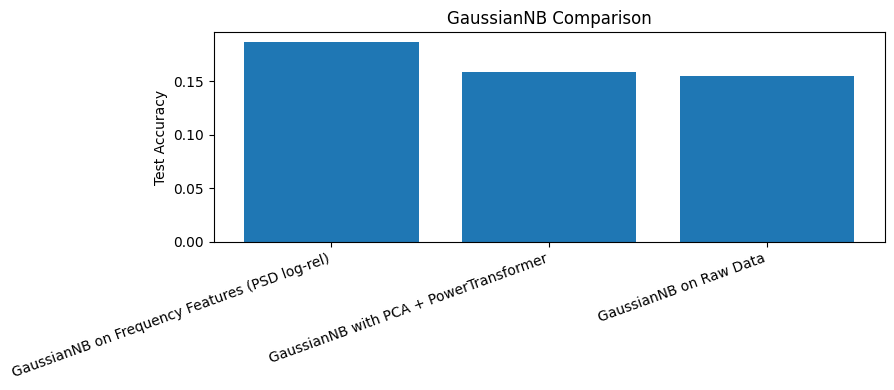


Best experiment: GaussianNB on Frequency Features (PSD log-rel)
Confusion matrix:
 [[415 284 413 423 746 258]
 [345 342 431 391 633 343]
 [361 254 591 408 772 306]
 [357 366 348 460 670 401]
 [373 259 388 529 711 270]
 [335 278 432 407 726 346]]

Classification report:
               precision    recall  f1-score   support

    backward       0.19      0.16      0.18      2539
     forward       0.19      0.14      0.16      2485
     landing       0.23      0.22      0.22      2692
        left       0.18      0.18      0.18      2602
       right       0.17      0.28      0.21      2530
     takeoff       0.18      0.14      0.16      2524

    accuracy                           0.19     15372
   macro avg       0.19      0.19      0.18     15372
weighted avg       0.19      0.19      0.18     15372



In [9]:
# Grouped-window experiments for GaussianNBTF
# Compares:
# 1) Raw window baseline
# 2) Raw + PowerTransformer + PCA(95%)
# 3) PSD band powers (+ optional Power/PCA, here enabled)

import numpy as np
import pandas as pd
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# ---------------------------
# 1) Config
# ---------------------------
fs = 125
window_size = 125
window_stride = 62   # true ~50% overlap for ws=125
var_smoothing_grid = np.logspace(-12, -2, 11)
random_state = 42

bands = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma": (30.0, 45.0),
}

# ---------------------------
# 2) Validation + grouped split by file
# ---------------------------
required_cols = {"src_filename", "label_txt"}
if not required_cols.issubset(set(eeg_data.columns)):
    raise ValueError("eeg_data must contain src_filename and label_txt")

exg_cols = [f"EXG Channel {i}" for i in range(16) if f"EXG Channel {i}" in eeg_data.columns]
if len(exg_cols) < 8:
    raise ValueError(f"Expected EXG columns, found only {len(exg_cols)}")

df = eeg_data.copy()
df = df[df["label_txt"].astype(str).str.len() > 0].copy()
df = df[["src_filename", "label_txt"] + exg_cols].copy()
df[exg_cols] = df[exg_cols].apply(pd.to_numeric, errors="coerce")
df[exg_cols] = df[exg_cols].replace([np.inf, -np.inf], np.nan)

file_label = df.groupby("src_filename")["label_txt"].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]
)

files = file_label.index.to_numpy()
file_labels_txt = file_label.values
label_names = sorted(pd.unique(file_labels_txt).tolist())
label_to_id = {lbl: i for i, lbl in enumerate(label_names)}
file_labels = np.array([label_to_id[x] for x in file_labels_txt], dtype=np.int32)

# 60/20/20 split at FILE level (train/val/test)
trainval_files, test_files = train_test_split(
    files, test_size=0.2, random_state=random_state, stratify=file_labels
)
trainval_labels = np.array([label_to_id[file_label.loc[f]] for f in trainval_files], dtype=np.int32)

train_files, val_files = train_test_split(
    trainval_files, test_size=0.25, random_state=random_state, stratify=trainval_labels
)

train_file_set = set(train_files)
train_rows = df[df["src_filename"].isin(train_file_set)]
train_medians = train_rows[exg_cols].median(numeric_only=True)

# ---------------------------
# 3) Feature extractors
# ---------------------------
def feat_raw_flatten(win_2d):
    # raw time-series values as features (channels concatenated in time)
    return win_2d.reshape(-1).astype(np.float32)

def feat_time_stats(win_2d):
    # your previous handcrafted stats baseline
    mean = np.mean(win_2d, axis=0)
    std = np.std(win_2d, axis=0)
    vmin = np.min(win_2d, axis=0)
    vmax = np.max(win_2d, axis=0)
    ptp = vmax - vmin
    energy = np.mean(win_2d * win_2d, axis=0)
    line_len = np.mean(np.abs(np.diff(win_2d, axis=0)), axis=0)
    return np.concatenate([mean, std, vmin, vmax, ptp, energy, line_len]).astype(np.float32)

def feat_psd_bands_logrel(win_2d, sfreq=125):
    # Welch PSD per channel: psd shape [freq_bins, channels]
    freqs, psd = welch(
        win_2d,
        fs=sfreq,
        nperseg=min(256, win_2d.shape[0]),
        noverlap=min(128, max(0, win_2d.shape[0] // 2)),
        axis=0
    )
    eps = 1e-12

    # Total power in analysis range (for relative powers)
    total_idx = (freqs >= 0.5) & (freqs < 45.0)
    total_power = np.trapezoid(psd[total_idx, :], freqs[total_idx], axis=0) + eps

    band_abs = []
    band_rel_log = []

    for lo, hi in bands.values():
        idx = (freqs >= lo) & (freqs < hi)
        if np.any(idx):
            bp = np.trapezoid(psd[idx, :], freqs[idx], axis=0)
        else:
            bp = np.zeros(win_2d.shape[1], dtype=np.float32)

        rel = bp / total_power
        band_abs.append(bp.astype(np.float32))
        band_rel_log.append(np.log1p(rel).astype(np.float32))

    # Unpack for ratios (order must match your bands dict)
    delta, theta, alpha, beta, gamma = band_abs

    # Common EEG ratios (with safe denom)
    theta_beta = theta / (beta + eps)
    alpha_beta = alpha / (beta + eps)
    theta_alpha = theta / (alpha + eps)

    # Final PSD feature vector:
    # 1) log-relative band powers
    # 2) selected band ratios
    return np.concatenate(
        band_rel_log + [
            np.log1p(theta_beta).astype(np.float32),
            np.log1p(alpha_beta).astype(np.float32),
            np.log1p(theta_alpha).astype(np.float32),
        ]
    ).astype(np.float32)

def build_window_dataset(file_list, medians, ws, stride, feature_fn):
    X_list, y_list, file_idx_list = [], [], []
    used_files, short_files = 0, 0

    file_to_idx = {fp: i for i, fp in enumerate(file_list)}

    for fp in file_list:
        part = df[df["src_filename"] == fp]
        if part.empty:
            continue

        sig_df = part[exg_cols].copy().fillna(medians).fillna(0.0)
        sig = sig_df.to_numpy(dtype=np.float32)
        n = sig.shape[0]
        if n < ws:
            short_files += 1
            continue

        lbl_id = label_to_id[file_label.loc[fp]]
        made = 0
        for start in range(0, n - ws + 1, stride):
            win = sig[start:start + ws, :]
            X_list.append(feature_fn(win))
            y_list.append(lbl_id)
            file_idx_list.append(file_to_idx[fp])
            made += 1

        if made > 0:
            used_files += 1

    if not X_list:
        raise ValueError("No windows generated. Reduce window_size or inspect file lengths.")

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int32)
    file_ids = np.array(file_idx_list, dtype=np.int32)
    return X, y, file_ids, used_files, short_files

# ---------------------------
# 4) Preprocessing helpers (Gaussianization + PCA)
# ---------------------------
def fit_preprocess(X_train, gaussianizer="none", pca_var=None):
    state = {"gaussianizer": gaussianizer, "transformer": None, "mu": None, "sd": None, "pca": None}

    if gaussianizer == "power":
        tr = PowerTransformer(method="yeo-johnson", standardize=True)
        Xp = tr.fit_transform(X_train)
        state["transformer"] = tr
    elif gaussianizer == "quantile":
        n_q = int(min(1000, X_train.shape[0]))
        tr = QuantileTransformer(n_quantiles=n_q, output_distribution="normal", random_state=42)
        Xp = tr.fit_transform(X_train)
        state["transformer"] = tr
    else:
        mu = X_train.mean(axis=0)
        sd = X_train.std(axis=0)
        sd[sd == 0] = 1.0
        Xp = (X_train - mu) / sd
        state["mu"] = mu.astype(np.float32)
        state["sd"] = sd.astype(np.float32)

    if pca_var is not None:
        pca = PCA(n_components=pca_var, svd_solver="full", whiten=False, random_state=42)
        Xp = pca.fit_transform(Xp)
        state["pca"] = pca

    return state, Xp.astype(np.float32)

def apply_preprocess(X, state):
    if state["transformer"] is not None:
        Xt = state["transformer"].transform(X)
    else:
        Xt = (X - state["mu"]) / state["sd"]

    if state["pca"] is not None:
        Xt = state["pca"].transform(Xt)

    return Xt.astype(np.float32)


def tune_var_smoothing(Xtr, ytr, Xva, yva, grid):
    best_vs, best_acc = None, -1.0
    for vs in grid:
        m = GaussianNBTF(var_smoothing=float(vs))
        m.fit(Xtr, ytr)
        pred = m.predict(Xva)
        acc = accuracy_score(yva, pred)
        if acc > best_acc:
            best_acc = acc
            best_vs = float(vs)
    return best_vs, best_acc


def file_level_metrics(y_true_win, y_pred_win, file_ids):
    # Majority vote per file ID
    y_true_file = []
    y_pred_file = []

    for fid in np.unique(file_ids):
        idx = np.where(file_ids == fid)[0]
        yt = y_true_win[idx]
        yp = y_pred_win[idx]

        y_true_file.append(int(np.bincount(yt).argmax()))
        y_pred_file.append(int(np.bincount(yp).argmax()))

    y_true_file = np.array(y_true_file, dtype=np.int32)
    y_pred_file = np.array(y_pred_file, dtype=np.int32)

    return accuracy_score(y_true_file, y_pred_file), y_true_file, y_pred_file

# ---------------------------
# 5) Experiment runner
# ---------------------------
def run_experiment(name, feature_fn, gaussianizer, pca_var):
    X_tr, y_tr, fid_tr, tr_used, tr_short = build_window_dataset(train_files, train_medians, window_size, window_stride, feature_fn)
    X_va, y_va, fid_va, va_used, va_short = build_window_dataset(val_files, train_medians, window_size, window_stride, feature_fn)
    X_te, y_te, fid_te, te_used, te_short = build_window_dataset(test_files, train_medians, window_size, window_stride, feature_fn)

    prep_state, Xtr_p = fit_preprocess(X_tr, gaussianizer=gaussianizer, pca_var=pca_var)
    Xva_p = apply_preprocess(X_va, prep_state)
    best_vs, val_acc = tune_var_smoothing(Xtr_p, y_tr, Xva_p, y_va, var_smoothing_grid)

    X_tv = np.vstack([X_tr, X_va]).astype(np.float32)
    y_tv = np.concatenate([y_tr, y_va]).astype(np.int32)
    final_state, Xtv_p = fit_preprocess(X_tv, gaussianizer=gaussianizer, pca_var=pca_var)
    Xte_p = apply_preprocess(X_te, final_state)

    model = GaussianNBTF(var_smoothing=best_vs)
    model.fit(Xtv_p, y_tv)

    y_pred = model.predict(Xte_p)
    test_acc_win = accuracy_score(y_te, y_pred)
    test_acc_file, y_true_file, y_pred_file = file_level_metrics(y_te, y_pred, fid_te)

    info = {
        "name": name,
        "gaussianizer": gaussianizer,
        "pca_var": pca_var,
        "best_var_smoothing": best_vs,
        "val_acc_window": val_acc,
        "test_acc_window": test_acc_win,
        "test_acc_file": test_acc_file,
        "train_windows": int(X_tr.shape[0]),
        "val_windows": int(X_va.shape[0]),
        "test_windows": int(X_te.shape[0]),
        "feature_dim_before_preproc": int(X_tr.shape[1]),
        "feature_dim_after_preproc": int(Xtv_p.shape[1]),
        "used_files_train": tr_used,
        "used_files_val": va_used,
        "used_files_test": te_used,
        "short_train": tr_short,
        "short_val": va_short,
        "short_test": te_short,
        "y_test": y_te,
        "y_pred": y_pred,
        "y_true_file": y_true_file,
        "y_pred_file": y_pred_file,
        "model": model,
        "preprocess_state": final_state,
    }
    return info

# ---------------------------
# 6) Run required comparisons
# ---------------------------
experiments = [
    ("GaussianNB on Raw Data", feat_raw_flatten, "none", None),
    ("GaussianNB with PCA + PowerTransformer", feat_raw_flatten, "power", 0.95),
    ("GaussianNB on Frequency Features (PSD log-rel)", feat_psd_bands_logrel, "quantile", 0.95),
]

results = []
artifacts = {}

for name, ff, gz, pca_v in experiments:
    out = run_experiment(name, ff, gz, pca_v)
    artifacts[name] = out
    results.append({
    "Experiment": out["name"],
    "Val_Acc_Window": out["val_acc_window"],
    "Test_Acc_Window": out["test_acc_window"],
    "Test_Acc_File": out["test_acc_file"],
    "Best_var_smoothing": out["best_var_smoothing"],
    "Dim_before": out["feature_dim_before_preproc"],
    "Dim_after": out["feature_dim_after_preproc"],
    "Train_windows": out["train_windows"],
    "Val_windows": out["val_windows"],
    "Test_windows": out["test_windows"],
})
    print(f"{out['name']}: val={out['val_acc_window']:.4f}, test={out['test_acc_window']:.4f}, vs={out['best_var_smoothing']:.1e}")

results_df = pd.DataFrame(results).sort_values("Test_Acc_Window", ascending=False).reset_index(drop=True)
print("\nComparative results:")
print(results_df)

# defense chart
plt.figure(figsize=(9, 4))
plt.bar(results_df["Experiment"], results_df["Test_Acc_Window"])
plt.ylabel("Test Accuracy")
plt.title("GaussianNB Comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# best model report
best_name = results_df.iloc[0]["Experiment"]
best_art = artifacts[best_name]
print("\nBest experiment:", best_name)
print("Confusion matrix:\n", confusion_matrix(best_art["y_test"], best_art["y_pred"]))
print("\nClassification report:\n", classification_report(
    best_art["y_test"], best_art["y_pred"],
    labels=np.arange(len(label_names)),
    target_names=label_names,
    zero_division=0
))

# Export variables expected by save cell (pick best)
model = best_art["model"]
X_train = None
X_test = None
y_train = None
y_test = best_art["y_test"]
feature_cols = exg_cols
keep = [f"f_{i}" for i in range(best_art["feature_dim_before_preproc"])]

In [10]:
# Save best trained model + full preprocessing metadata
best_name = results_df.iloc[0]["Experiment"]
best_art = artifacts[best_name]
state = best_art["preprocess_state"]

meta = {
    "pipeline_name": best_name,
    "label_names": label_names,
    "feature_cols": feature_cols,
    "kept_feature_cols": keep,
    "window_size": window_size,
    "window_stride": window_stride,
    "sampling_rate": fs,
    "bands": bands,
    "best_var_smoothing": best_art["best_var_smoothing"],
    "gaussianizer": state["gaussianizer"],

    "mu": state["mu"] if state["mu"] is not None else None,
    "sd": state["sd"] if state["sd"] is not None else None,
    "train_medians": train_medians.to_dict(),

    "transformer": state["transformer"],
    "pca": state["pca"],
}

out_path = "gaussiannb_trained.pth"
save_model(out_path, best_art["model"], meta)
print(f"Saved trained model to {out_path} using pipeline: {best_name}")

Saved trained model to gaussiannb_trained.pth using pipeline: GaussianNB on Frequency Features (PSD log-rel)


In [11]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import welch
from gaussiannb_model import load_model

# ---------------------------
# 1) Load saved model + metadata
# ---------------------------
model_path = "gaussiannb_trained.pth"
model, meta = load_model(model_path)

pipeline_name = meta.get("pipeline_name", "")
fs = int(meta.get("sampling_rate", 125))
ws = int(meta.get("window_size", 125))
stride = int(meta.get("window_stride", 62))
bands = meta.get("bands", {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta": (13.0, 30.0),
    "gamma": (30.0, 45.0),
})

label_names = meta["label_names"]
feature_cols = meta.get("feature_cols", [f"EXG Channel {i}" for i in range(16)])

transformer = meta.get("transformer", None)
pca = meta.get("pca", None)
mu = meta.get("mu", None)
sd = meta.get("sd", None)

# Optional, only if you later add this to saved meta
train_medians = meta.get("train_medians", None)

# ---------------------------
# 2) File loader (same parsing spirit as training)
# ---------------------------
def load_exg16_file(fp: Path, wanted_cols):
    parse_attempts = [
        dict(sep=r"\s*,\s*", engine="python", comment="%", on_bad_lines="skip"),
        dict(sep="\t", engine="python", header=None, on_bad_lines="skip"),
        dict(sep=",", engine="python", header=None, on_bad_lines="skip"),
    ]

    for kw in parse_attempts:
        try:
            df = pd.read_csv(fp, **kw)
            if df is None or df.empty:
                continue

            exg_named = [c for c in df.columns if "exg channel" in str(c).lower()]
            if len(exg_named) >= len(wanted_cols):
                exg = df[exg_named[:len(wanted_cols)]].copy()
            else:
                if df.shape[1] >= 17 and len(wanted_cols) == 16:
                    exg = df.iloc[:, 1:17].copy()
                elif df.shape[1] >= len(wanted_cols):
                    exg = df.iloc[:, :len(wanted_cols)].copy()
                else:
                    continue

            exg = exg.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
            exg = exg.dropna(how="all")
            if exg.shape[0] == 0:
                continue

            exg.columns = wanted_cols
            return exg

        except Exception:
            continue

    return None

# ---------------------------
# 3) Feature extractors (must match training experiment)
# ---------------------------
def feat_raw_flatten(win_2d):
    return win_2d.reshape(-1).astype(np.float32)

def feat_psd_bands_logrel(win_2d, sfreq=125):
    freqs, psd = welch(
        win_2d,
        fs=sfreq,
        nperseg=min(256, win_2d.shape[0]),
        noverlap=min(128, max(0, win_2d.shape[0] // 2)),
        axis=0
    )
    eps = 1e-12
    total_idx = (freqs >= 0.5) & (freqs < 45.0)
    total_power = np.trapezoid(psd[total_idx, :], freqs[total_idx], axis=0) + eps

    band_abs, band_rel_log = [], []
    for lo, hi in bands.values():
        idx = (freqs >= lo) & (freqs < hi)
        bp = np.trapezoid(psd[idx, :], freqs[idx], axis=0) if np.any(idx) else np.zeros(win_2d.shape[1], dtype=np.float32)
        rel = bp / total_power
        band_abs.append(bp.astype(np.float32))
        band_rel_log.append(np.log1p(rel).astype(np.float32))

    delta, theta, alpha, beta, gamma = band_abs
    return np.concatenate(
        band_rel_log + [
            np.log1p(theta / (beta + eps)).astype(np.float32),
            np.log1p(alpha / (beta + eps)).astype(np.float32),
            np.log1p(theta / (alpha + eps)).astype(np.float32),
        ]
    ).astype(np.float32)

def pick_feature_fn(name):
    if "PSD" in name:
        return feat_psd_bands_logrel
    return feat_raw_flatten

feature_fn = pick_feature_fn(pipeline_name)

# ---------------------------
# 4) Build window features from one file
# ---------------------------
def build_features_for_file(exg_df, ws, stride, feature_fn, train_medians=None):
    sig_df = exg_df.copy()

    # If train medians were saved, this is exact with training missing-value policy.
    if train_medians is not None:
        med = pd.Series(train_medians)
        sig_df = sig_df.fillna(med).fillna(0.0)
    else:
        # Fallback if train_medians not saved
        sig_df = sig_df.fillna(sig_df.median(numeric_only=True)).fillna(0.0)

    sig = sig_df.to_numpy(dtype=np.float32)
    n = sig.shape[0]
    if n < ws:
        raise ValueError(f"Signal too short ({n}) for window_size={ws}")

    X_list = []
    for start in range(0, n - ws + 1, stride):
        win = sig[start:start + ws, :]
        X_list.append(feature_fn(win))

    return np.vstack(X_list).astype(np.float32)

# ---------------------------
# 5) Apply saved preprocessing path exactly (transformer -> standardize fallback -> PCA)
# ---------------------------
def apply_saved_preprocess(X, transformer, mu, sd, pca):
    if transformer is not None:
        Xt = transformer.transform(X)
    else:
        if mu is None or sd is None:
            raise ValueError("No transformer and no mu/sd in metadata.")
        mu_arr = np.asarray(mu, dtype=np.float32)
        sd_arr = np.asarray(sd, dtype=np.float32)
        sd_arr[sd_arr == 0] = 1.0
        Xt = (X - mu_arr) / sd_arr

    if pca is not None:
        Xt = pca.transform(Xt)

    return Xt.astype(np.float32)

# ---------------------------
# 6) Predict one file
# ---------------------------
def predict_file(file_path):
    fp = Path(file_path)
    exg = load_exg16_file(fp, feature_cols)
    if exg is None:
        raise ValueError(f"Could not parse EXG channels from file: {fp}")

    Xw = build_features_for_file(exg, ws, stride, feature_fn, train_medians=train_medians)
    Xp = apply_saved_preprocess(Xw, transformer, mu, sd, pca)

    y_win = model.predict(Xp)
    p_win = model.predict_proba(Xp)

    # Aggregate window predictions to one file-level prediction
    y_file = int(np.bincount(y_win).argmax())
    p_file = p_win.mean(axis=0)
    y_file_prob = int(np.argmax(p_file))

    return {
        "file": str(fp),
        "n_windows": int(Xw.shape[0]),
        "window_pred_ids": y_win,
        "window_pred_labels": [label_names[i] for i in y_win],
        "file_pred_label_majority": label_names[y_file],
        "file_pred_label_meanprob": label_names[y_file_prob],
        "file_prob_mean": p_file,
    }

# Example usage
test_file = "/home/prasndhdl/Downloads/avatar/Avatar-PrashantD_Forked/final_raw_forward.csv"
out = predict_file(test_file)
print("Pipeline:", pipeline_name)
print("Windows:", out["n_windows"])
print("Pred (majority):", out["file_pred_label_majority"])
print("Pred (mean prob):", out["file_pred_label_meanprob"])
print("Mean probs:")
for i, p in enumerate(out["file_prob_mean"]):
    print(f"  {label_names[i]}: {p:.4f}")

Pipeline: GaussianNB on Frequency Features (PSD log-rel)
Windows: 5689
Pred (majority): right
Pred (mean prob): right
Mean probs:
  backward: 0.1607
  forward: 0.1789
  landing: 0.1586
  left: 0.1607
  right: 0.1840
  takeoff: 0.1571


In [12]:
# ============================================================
# Cell 1: Imports + sanity checks
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from scipy import stats

assert "artifacts" in globals(), "Run the experiment cell first (artifacts missing)."
assert "results_df" in globals(), "Run the experiment cell first (results_df missing)."
assert "label_names" in globals(), "Run the experiment cell first (label_names missing)."

exp_names = list(artifacts.keys())
print("Experiments found:", exp_names)
display(results_df)

Experiments found: ['GaussianNB on Raw Data', 'GaussianNB with PCA + PowerTransformer', 'GaussianNB on Frequency Features (PSD log-rel)']


,Experiment,Val_Acc_Window,Test_Acc_Window,Test_Acc_File,Best_var_smoothing,Dim_before,Dim_after,Train_windows,Val_windows,Test_windows
0,GaussianNB on Frequency Features (PSD log-rel),0.201708,0.186378,0.199721,1.000000e-12,128,35,46451,15225,15372
1,GaussianNB with PCA + PowerTransformer,0.177603,0.158600,0.164804,1.000000e-12,2000,12,46451,15225,15372
2,GaussianNB on Raw Data,0.158949,0.154632,0.160615,1.000000e-12,2000,2000,46451,15225,15372


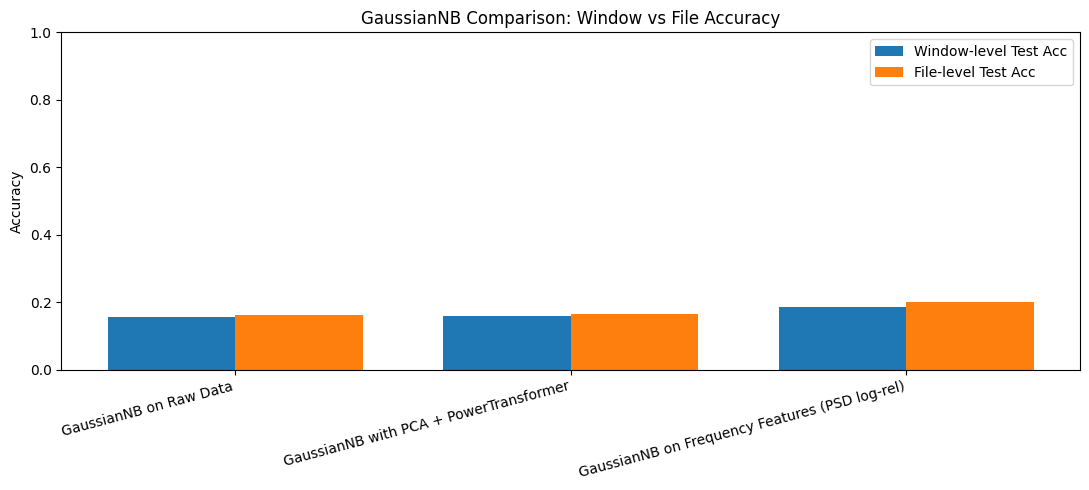

In [13]:
# ============================================================
# Cell 2: Defense chart (Window vs File accuracy side-by-side)
# ============================================================
plot_df = results_df.copy()
plot_df = plot_df.set_index("Experiment").loc[exp_names].reset_index()

x = np.arange(len(plot_df))
w = 0.38

plt.figure(figsize=(11, 5))
plt.bar(x - w/2, plot_df["Test_Acc_Window"], width=w, label="Window-level Test Acc")
plt.bar(x + w/2, plot_df["Test_Acc_File"], width=w, label="File-level Test Acc")
plt.xticks(x, plot_df["Experiment"], rotation=15, ha="right")
plt.ylim(0, 1.0)
plt.ylabel("Accuracy")
plt.title("GaussianNB Comparison: Window vs File Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

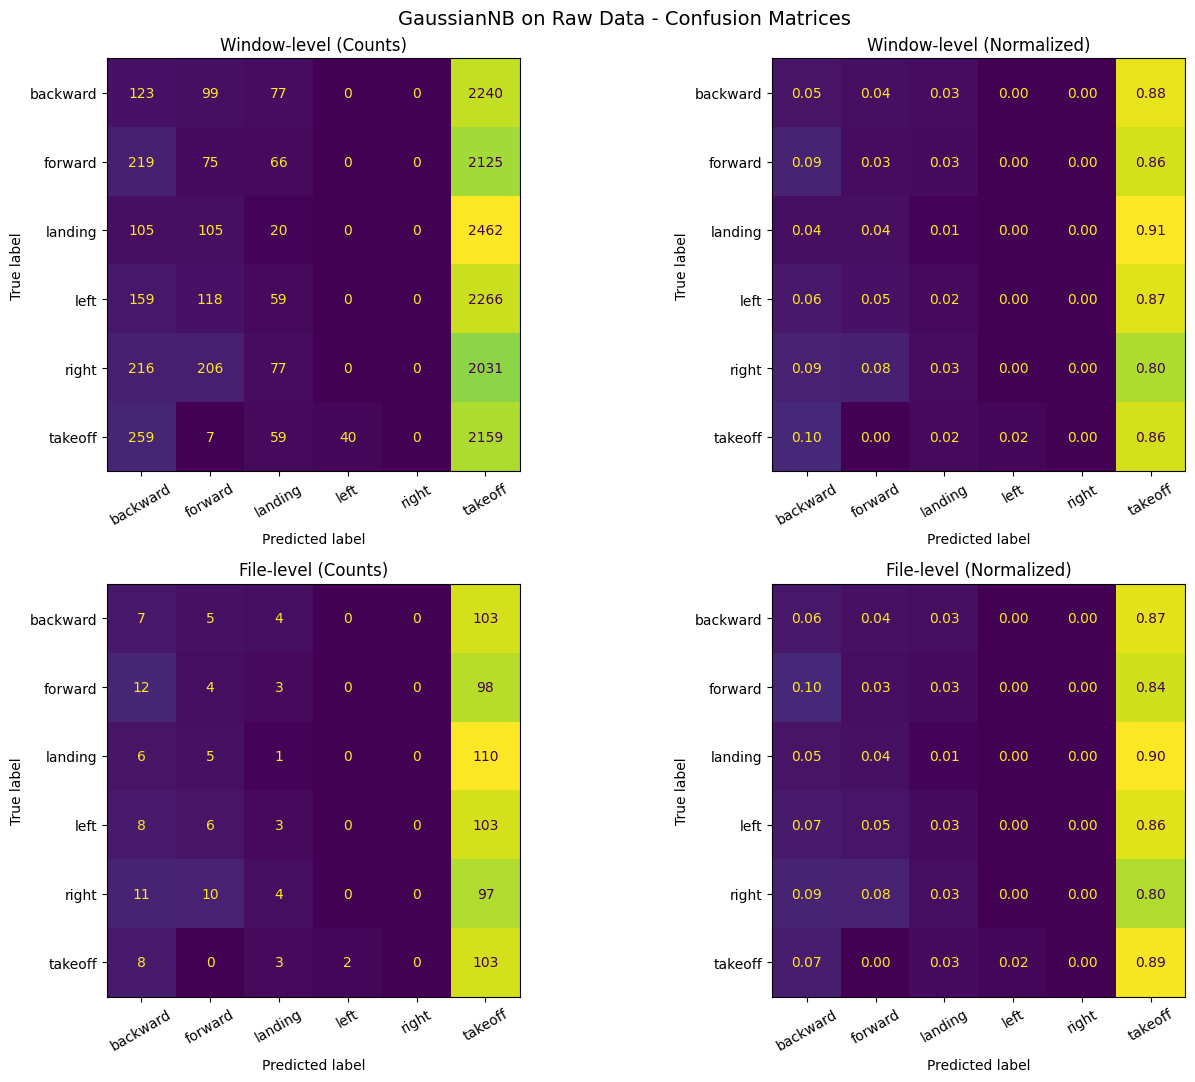

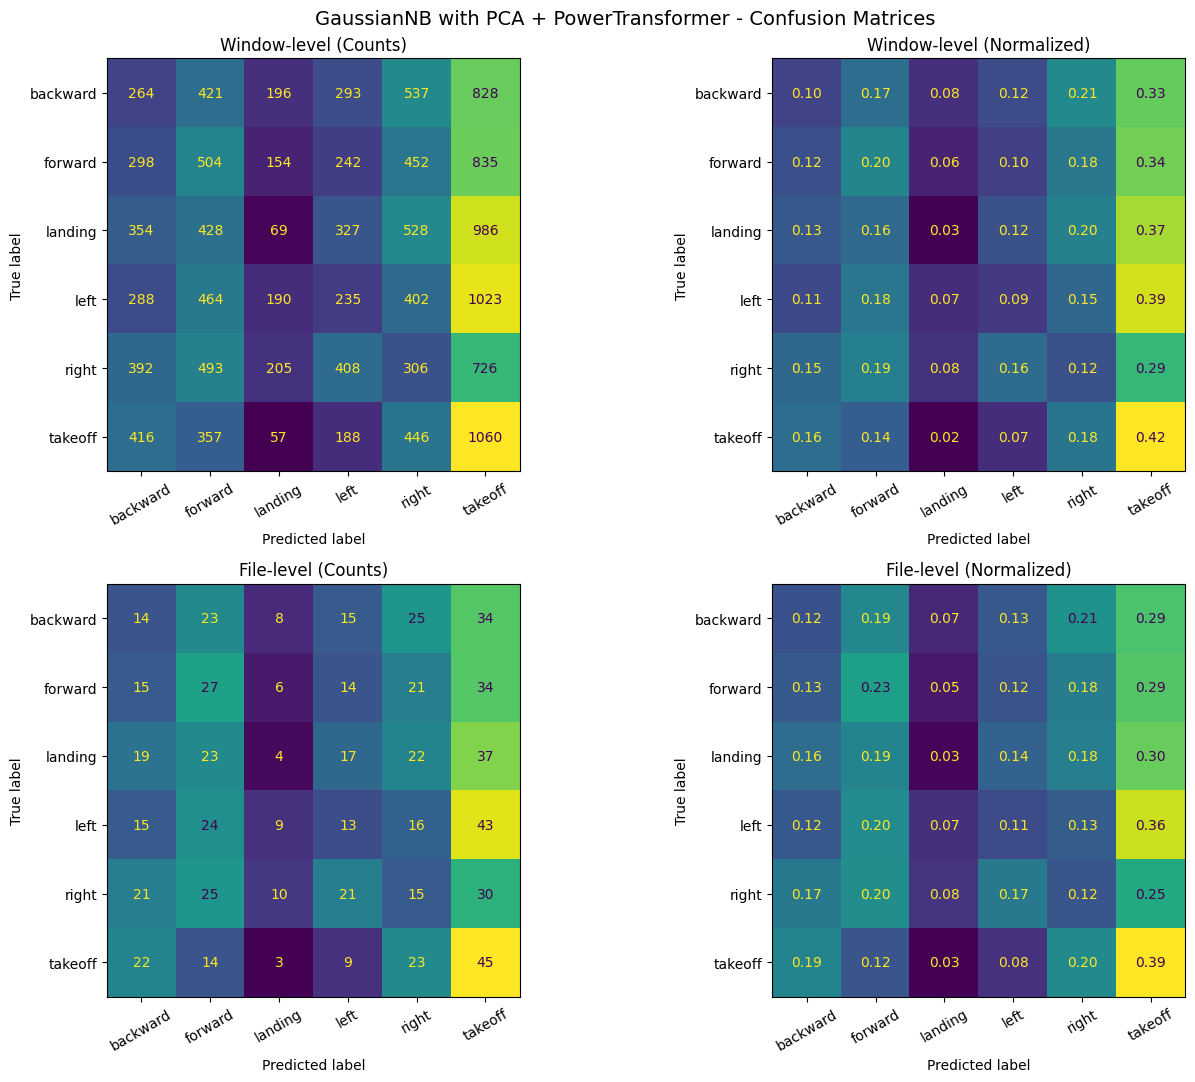

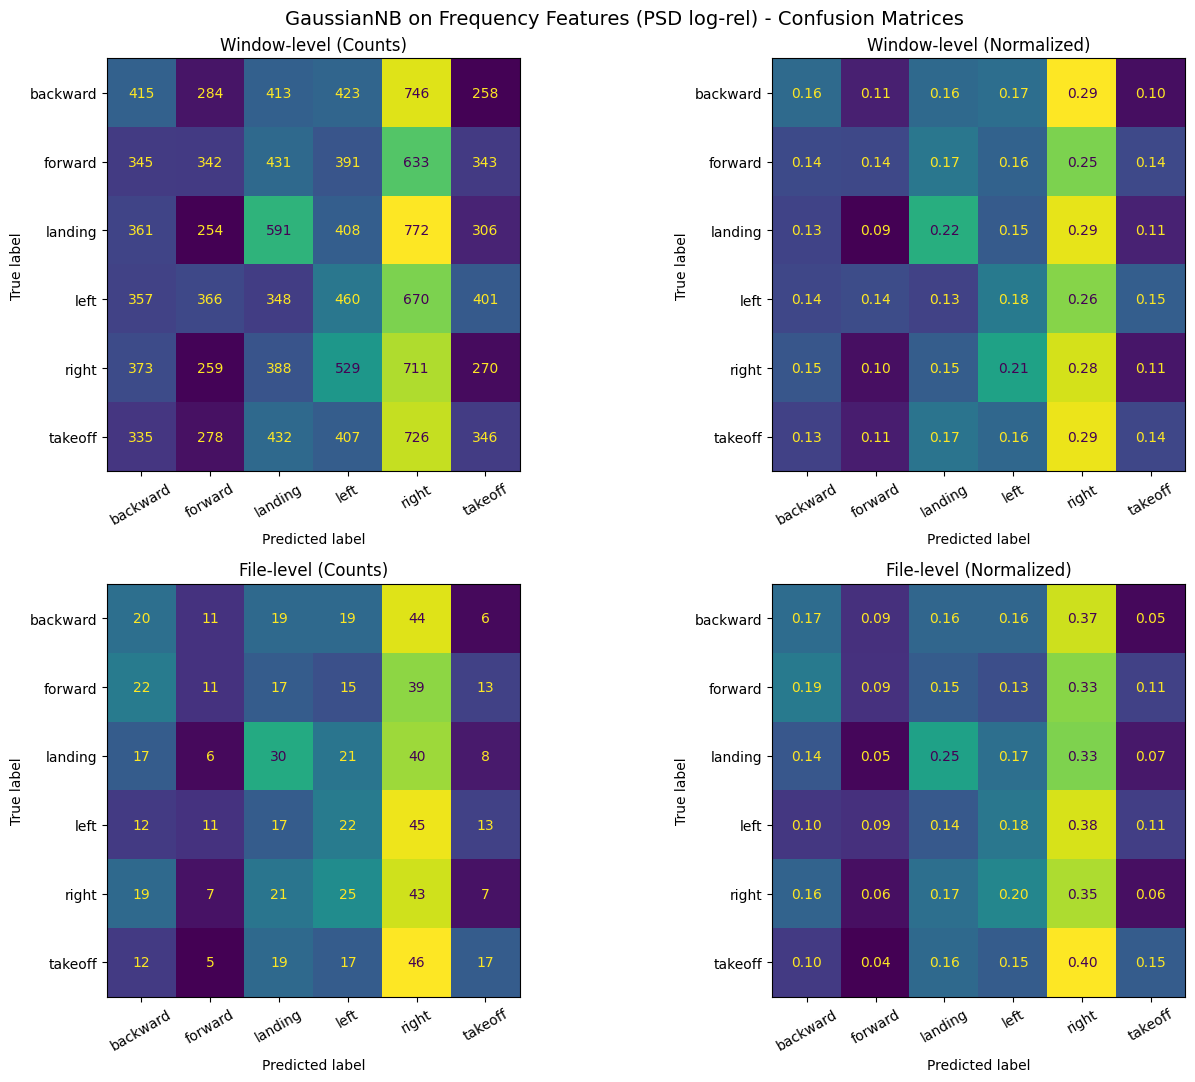

In [14]:
# ============================================================
# Cell 3: Confusion matrices for ALL experiments
# - Window-level (raw counts + normalized)
# - File-level (raw counts + normalized)
# ============================================================
for name, art in artifacts.items():
    y_tw, y_pw = art["y_test"], art["y_pred"]
    y_tf, y_pf = art["y_true_file"], art["y_pred_file"]

    cm_w = confusion_matrix(y_tw, y_pw, labels=np.arange(len(label_names)))
    cm_w_n = confusion_matrix(y_tw, y_pw, labels=np.arange(len(label_names)), normalize="true")

    cm_f = confusion_matrix(y_tf, y_pf, labels=np.arange(len(label_names)))
    cm_f_n = confusion_matrix(y_tf, y_pf, labels=np.arange(len(label_names)), normalize="true")

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(f"{name} - Confusion Matrices", fontsize=14)

    ConfusionMatrixDisplay(cm_w, display_labels=label_names).plot(ax=axes[0, 0], xticks_rotation=30, colorbar=False)
    axes[0, 0].set_title("Window-level (Counts)")

    ConfusionMatrixDisplay(cm_w_n, display_labels=label_names).plot(ax=axes[0, 1], xticks_rotation=30, colorbar=False, values_format=".2f")
    axes[0, 1].set_title("Window-level (Normalized)")

    ConfusionMatrixDisplay(cm_f, display_labels=label_names).plot(ax=axes[1, 0], xticks_rotation=30, colorbar=False)
    axes[1, 0].set_title("File-level (Counts)")

    ConfusionMatrixDisplay(cm_f_n, display_labels=label_names).plot(ax=axes[1, 1], xticks_rotation=30, colorbar=False, values_format=".2f")
    axes[1, 1].set_title("File-level (Normalized)")

    plt.tight_layout()
    plt.show()

,Experiment,Class,Precision,Recall,F1,Support
0,GaussianNB on Raw Data,backward,0.113784,0.048444,0.067956,2539.0
1,GaussianNB on Raw Data,forward,0.122951,0.030181,0.048465,2485.0
2,GaussianNB on Raw Data,landing,0.055866,0.007429,0.013115,2692.0
3,GaussianNB on Raw Data,left,0.000000,0.000000,0.000000,2602.0
4,GaussianNB on Raw Data,right,0.000000,0.000000,0.000000,2530.0


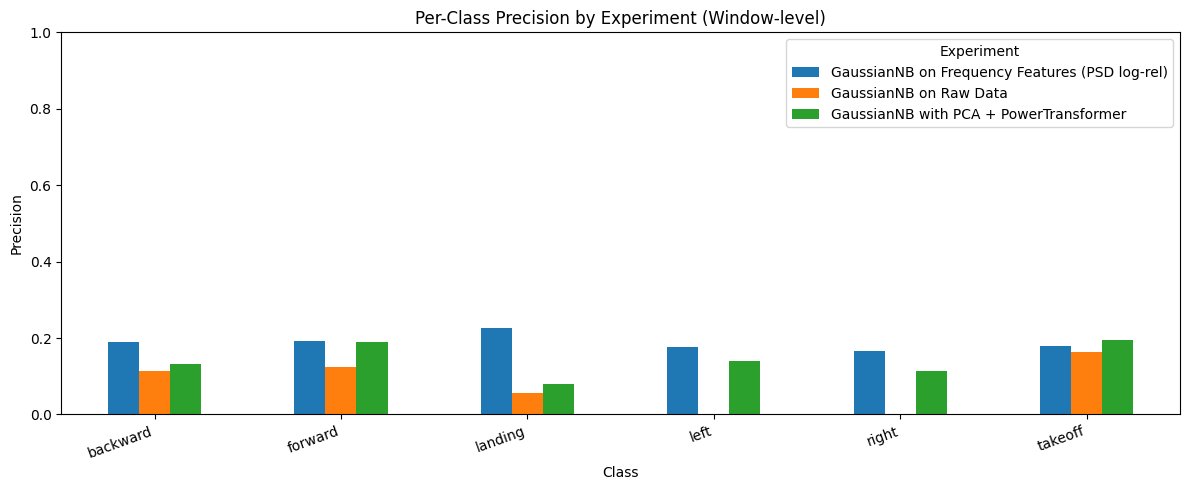

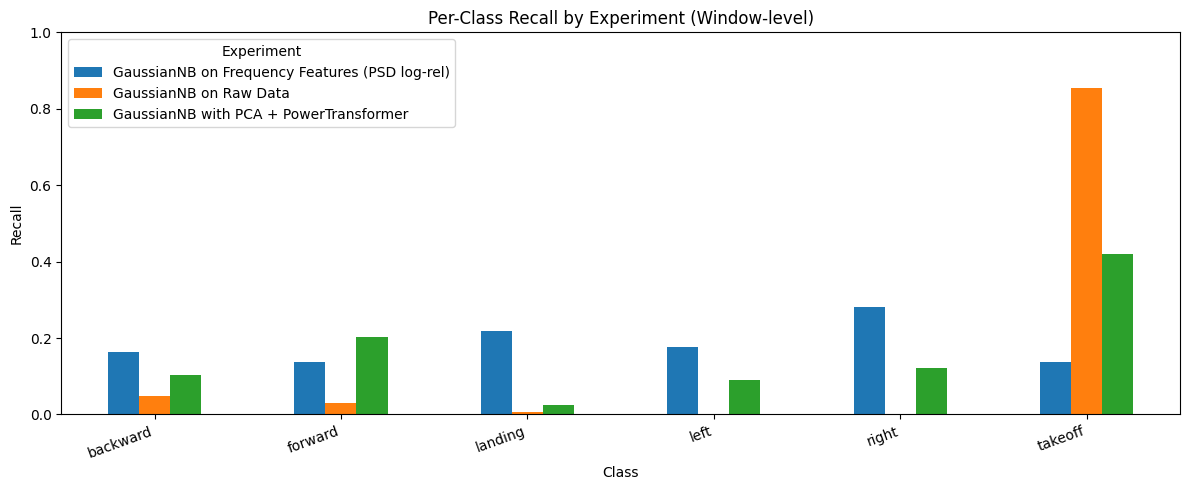

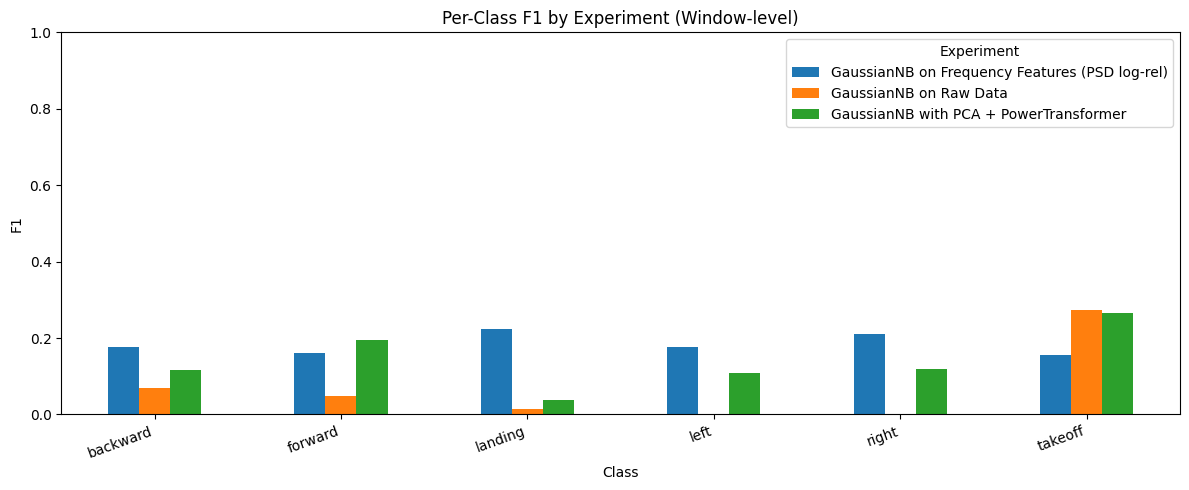

In [15]:
# ============================================================
# Cell 4: Per-class metrics comparison (precision/recall/F1)
# ============================================================
rows = []
for name, art in artifacts.items():
    rep = classification_report(
        art["y_test"], art["y_pred"],
        labels=np.arange(len(label_names)),
        target_names=label_names,
        zero_division=0,
        output_dict=True
    )
    for cls in label_names:
        rows.append({
            "Experiment": name,
            "Class": cls,
            "Precision": rep[cls]["precision"],
            "Recall": rep[cls]["recall"],
            "F1": rep[cls]["f1-score"],
            "Support": rep[cls]["support"]
        })

class_df = pd.DataFrame(rows)
display(class_df.head())

metrics = ["Precision", "Recall", "F1"]
for m in metrics:
    pivot = class_df.pivot(index="Class", columns="Experiment", values=m).reindex(label_names)
    pivot.plot(kind="bar", figsize=(12, 5))
    plt.ylim(0, 1.0)
    plt.ylabel(m)
    plt.title(f"Per-Class {m} by Experiment (Window-level)")
    plt.xticks(rotation=20, ha="right")
    plt.legend(title="Experiment")
    plt.tight_layout()
    plt.show()

In [16]:
# ============================================================
# Cell 5: Full textual reports for ALL experiments
# ============================================================
for name, art in artifacts.items():
    print("=" * 90)
    print(name)
    print("- Window-level classification report")
    print(classification_report(
        art["y_test"], art["y_pred"],
        labels=np.arange(len(label_names)),
        target_names=label_names,
        zero_division=0
    ))
    print("- File-level classification report")
    print(classification_report(
        art["y_true_file"], art["y_pred_file"],
        labels=np.arange(len(label_names)),
        target_names=label_names,
        zero_division=0
    ))

GaussianNB on Raw Data
- Window-level classification report
              precision    recall  f1-score   support

    backward       0.11      0.05      0.07      2539
     forward       0.12      0.03      0.05      2485
     landing       0.06      0.01      0.01      2692
        left       0.00      0.00      0.00      2602
       right       0.00      0.00      0.00      2530
     takeoff       0.16      0.86      0.27      2524

    accuracy                           0.15     15372
   macro avg       0.08      0.16      0.07     15372
weighted avg       0.08      0.15      0.07     15372

- File-level classification report
              precision    recall  f1-score   support

    backward       0.13      0.06      0.08       119
     forward       0.13      0.03      0.05       117
     landing       0.06      0.01      0.01       122
        left       0.00      0.00      0.00       120
       right       0.00      0.00      0.00       122
     takeoff       0.17      0.89    

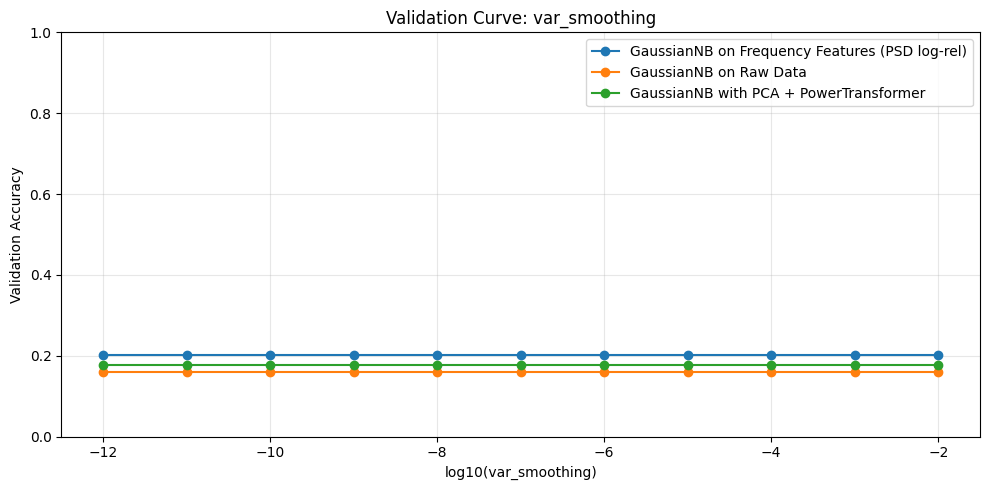

,Experiment,var_smoothing,log10_vs,val_acc
22,GaussianNB on Frequency Features (PSD log-rel),1.000000e-12,-12.0,0.201708
23,GaussianNB on Frequency Features (PSD log-rel),1.000000e-11,-11.0,0.201708
24,GaussianNB on Frequency Features (PSD log-rel),1.000000e-10,-10.0,0.201708
25,GaussianNB on Frequency Features (PSD log-rel),1.000000e-09,-9.0,0.201708
26,GaussianNB on Frequency Features (PSD log-rel),1.000000e-08,-8.0,0.201708
27,GaussianNB on Frequency Features (PSD log-rel),1.000000e-07,-7.0,0.201708
28,GaussianNB on Frequency Features (PSD log-rel),1.000000e-06,-6.0,0.201708
29,GaussianNB on Frequency Features (PSD log-rel),1.000000e-05,-5.0,0.201708
30,GaussianNB on Frequency Features (PSD log-rel),1.000000e-04,-4.0,0.201708
31,GaussianNB on Frequency Features (PSD log-rel),1.000000e-03,-3.0,0.201708


In [17]:
# ============================================================
# Cell 6: Optional var_smoothing curves (requires helper funcs
# and data split vars from your experiment cell to still exist)
# ============================================================
required = [
    "build_window_dataset", "fit_preprocess", "apply_preprocess",
    "GaussianNBTF", "accuracy_score", "train_files", "val_files",
    "train_medians", "window_size", "window_stride", "var_smoothing_grid",
    "feat_raw_flatten", "feat_psd_bands_logrel"
]
missing = [r for r in required if r not in globals()]

if missing:
    print("Skipping var_smoothing curves. Missing symbols:", missing)
else:
    # Match experiments exactly
    exp_cfg = [
        ("GaussianNB on Raw Data", feat_raw_flatten, "none", None),
        ("GaussianNB with PCA + PowerTransformer", feat_raw_flatten, "power", 0.95),
        ("GaussianNB on Frequency Features (PSD log-rel)", feat_psd_bands_logrel, "quantile", 0.95),
    ]

    curves = []
    for name, ff, gz, pca_v in exp_cfg:
        X_tr, y_tr, _, _, _ = build_window_dataset(train_files, train_medians, window_size, window_stride, ff)
        X_va, y_va, _, _, _ = build_window_dataset(val_files, train_medians, window_size, window_stride, ff)

        state, Xtr_p = fit_preprocess(X_tr, gaussianizer=gz, pca_var=pca_v)
        Xva_p = apply_preprocess(X_va, state)

        for vs in var_smoothing_grid:
            m = GaussianNBTF(var_smoothing=float(vs))
            m.fit(Xtr_p, y_tr)
            pred = m.predict(Xva_p)
            acc = accuracy_score(y_va, pred)
            curves.append({
                "Experiment": name,
                "var_smoothing": float(vs),
                "log10_vs": np.log10(float(vs)),
                "val_acc": acc
            })

    curve_df = pd.DataFrame(curves)

    plt.figure(figsize=(10, 5))
    for name, g in curve_df.groupby("Experiment"):
        g = g.sort_values("log10_vs")
        plt.plot(g["log10_vs"], g["val_acc"], marker="o", label=name)

    plt.xlabel("log10(var_smoothing)")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Curve: var_smoothing")
    plt.ylim(0, 1.0)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    display(curve_df.sort_values(["Experiment", "var_smoothing"]))

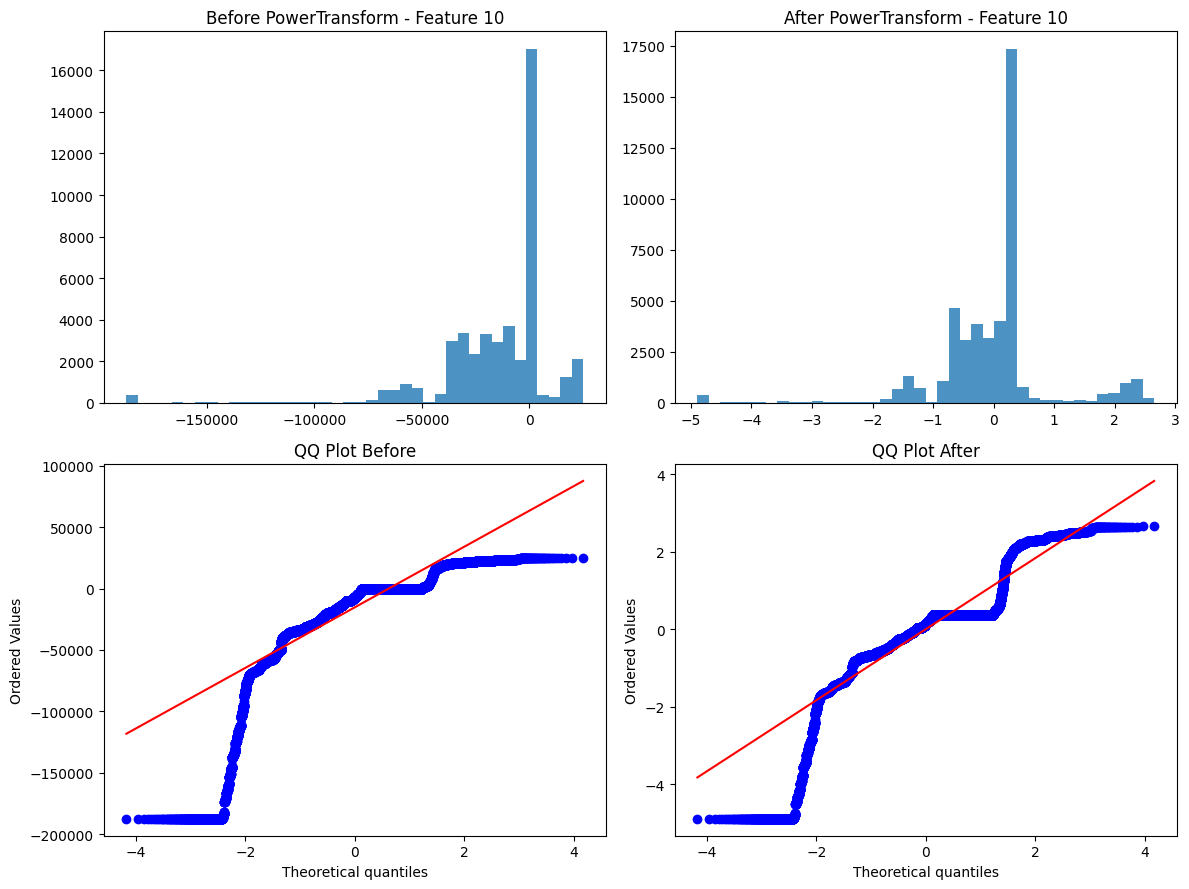

Lower is closer to Gaussian (0 skew, 0 excess kurtosis):


,mean_abs_skew_before,mean_abs_skew_after,mean_abs_kurt_before,mean_abs_kurt_after
0,3.027698,1.120573,97.841599,41.357555


In [18]:
# ============================================================
# Cell 7: Optional Gaussianization evidence (QQ + hist before/after)
# Uses one pipeline to demonstrate normality shift.
# ============================================================
required = [
    "build_window_dataset", "fit_preprocess", "train_files", "train_medians",
    "window_size", "window_stride", "feat_raw_flatten"
]
missing = [r for r in required if r not in globals()]

if missing:
    print("Skipping gaussianization diagnostics. Missing symbols:", missing)
else:
    # Demonstrate on the same raw features used in pipeline 2
    X_tr_raw, y_tr_raw, _, _, _ = build_window_dataset(
        train_files, train_medians, window_size, window_stride, feat_raw_flatten
    )
    state_power, X_tr_power = fit_preprocess(X_tr_raw, gaussianizer="power", pca_var=None)

    # Pick a stable feature index
    idx = min(10, X_tr_raw.shape[1] - 1)
    x_before = X_tr_raw[:, idx]
    x_after = X_tr_power[:, idx]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes[0, 0].hist(x_before, bins=40, alpha=0.8)
    axes[0, 0].set_title(f"Before PowerTransform - Feature {idx}")
    axes[0, 1].hist(x_after, bins=40, alpha=0.8)
    axes[0, 1].set_title(f"After PowerTransform - Feature {idx}")

    stats.probplot(x_before, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title("QQ Plot Before")
    stats.probplot(x_after, dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title("QQ Plot After")

    plt.tight_layout()
    plt.show()

    # quick skew/kurtosis check on first N features
    N = min(50, X_tr_raw.shape[1])
    skew_before = pd.Series(stats.skew(X_tr_raw[:, :N], axis=0, nan_policy="omit"))
    skew_after = pd.Series(stats.skew(X_tr_power[:, :N], axis=0, nan_policy="omit"))
    kurt_before = pd.Series(stats.kurtosis(X_tr_raw[:, :N], axis=0, nan_policy="omit"))
    kurt_after = pd.Series(stats.kurtosis(X_tr_power[:, :N], axis=0, nan_policy="omit"))

    diag = pd.DataFrame({
        "mean_abs_skew_before": [np.nanmean(np.abs(skew_before))],
        "mean_abs_skew_after": [np.nanmean(np.abs(skew_after))],
        "mean_abs_kurt_before": [np.nanmean(np.abs(kurt_before))],
        "mean_abs_kurt_after": [np.nanmean(np.abs(kurt_after))]
    })
    print("Lower is closer to Gaussian (0 skew, 0 excess kurtosis):")
    display(diag)

In [19]:
results_df = pd.DataFrame(results).sort_values("Test_Acc_File", ascending=False).reset_index(drop=True)

In [20]:
# Reload model module to ensure latest save_model is in scope
import importlib, gaussiannb_model
importlib.reload(gaussiannb_model)
from gaussiannb_model import GaussianNBTF, save_model